# 01. Hybrid Risk Scoring

This notebook combines four complementary wash-trading signals:

- `tabular_score`: wallet feature model
- `motif_score`: graph motif and local-structure model
- `gnn_score`: GraphSAGE message-passing model
- `anomaly_score`: unsupervised anomaly detector

The final layer is a calibrated logistic meta-model trained on the validation split.

Presentation framing:

> Instead of one classifier, we built a multi-signal fraud intelligence system.


In [13]:
import importlib
import hybrid_models.hybrid_model_utils as hmu

importlib.reload(hmu)
run_hybrid_experiment = hmu.run_hybrid_experiment


In [14]:
from pathlib import Path
import sys

import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "hybrid_models" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from hybrid_models.hybrid_model_utils import (
    plot_evaluation_dashboard,
    plot_meta_coefficients,
    plot_signal_correlation,
    run_hybrid_experiment,
    top_hybrid_alerts,
)


In [15]:
FEATURE_GROUP = "eth_twitter_combined_features"
ADD_GRAPH_STATS = False
RANDOM_STATE = 42
TABULAR_MODEL_NAME = "xgboost"
MOTIF_MODEL_NAME = "xgboost"
GNN_MODEL_NAME = "graphsage"
GNN_HIDDEN_DIM = 64
GNN_DROPOUT = 0.2
GNN_LEARNING_RATE = 1e-3
GNN_WEIGHT_DECAY = 1e-4
GNN_EPOCHS = 100
GNN_PATIENCE = 15
THRESHOLD_OBJECTIVE = "f1"


In [16]:
experiment = run_hybrid_experiment(
    feature_group=FEATURE_GROUP,
    add_graph_stats=ADD_GRAPH_STATS,
    random_state=RANDOM_STATE,
    tabular_model_name=TABULAR_MODEL_NAME,
    motif_model_name=MOTIF_MODEL_NAME,
    gnn_model_name=GNN_MODEL_NAME,
    gnn_hidden_dim=GNN_HIDDEN_DIM,
    gnn_dropout=GNN_DROPOUT,
    gnn_learning_rate=GNN_LEARNING_RATE,
    gnn_weight_decay=GNN_WEIGHT_DECAY,
    gnn_epochs=GNN_EPOCHS,
    gnn_patience=GNN_PATIENCE,
    threshold_objective=THRESHOLD_OBJECTIVE,
)

display(experiment["comparison_df"])


,signal,Threshold,PR-AUC,ROC-AUC,F1,Precision,Recall,Specificity,NPV,Balanced-Accuracy,...,Brier-Score,Log-Loss,Accuracy,TP,FP,TN,FN,TopK,Precision@K,Recall@K
4,hybrid_meta,0.900,0.891893,0.971108,0.809969,0.855263,0.769231,0.983471,0.971068,0.876351,...,0.052073,0.185680,0.959333,130,22,1309,39,169,0.810651,0.810651
1,motif,0.925,0.858352,0.969098,0.739437,0.913043,0.621302,0.992487,0.953791,0.806894,...,0.050102,0.164437,0.950667,105,10,1321,64,169,0.745562,0.745562
2,gnn,0.775,0.736243,0.933791,0.658385,0.692810,0.627219,0.964688,0.953229,0.795954,...,0.093927,0.322430,0.926667,106,47,1284,63,169,0.674556,0.674556
0,tabular,0.650,0.528431,0.860504,0.538462,0.475113,0.621302,0.912847,0.949961,0.767075,...,0.124727,0.398775,0.880000,105,116,1215,64,169,0.538462,0.538462
3,anomaly,0.300,0.254880,0.757832,0.313433,0.270386,0.372781,0.872276,0.916338,0.622529,...,0.101164,0.328182,0.816000,63,170,1161,106,169,0.284024,0.284024


,signal,coefficient
1,motif_score,1.835559
0,tabular_score,1.108245
2,gnn_score,0.731978
3,anomaly_score,-0.093187


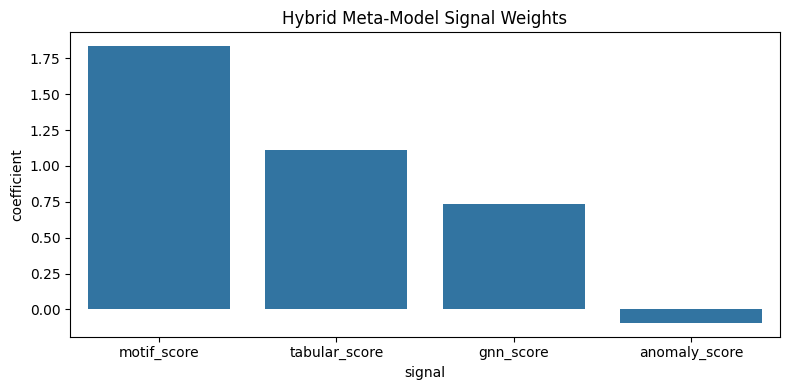

In [17]:
display(experiment["meta_result"]["coefficient_df"])
plot_meta_coefficients(experiment["meta_result"]["coefficient_df"])


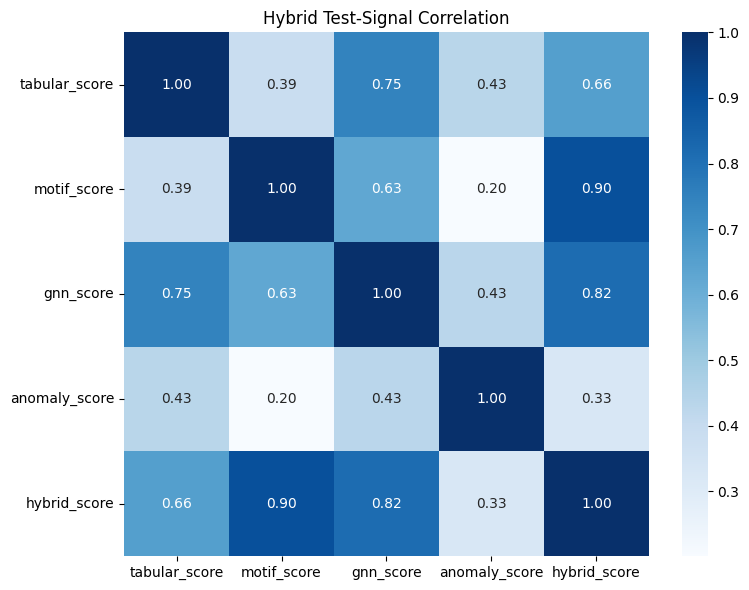

In [18]:
plot_signal_correlation(
    experiment["test_signal_df"],
    title="Hybrid Test-Signal Correlation",
)


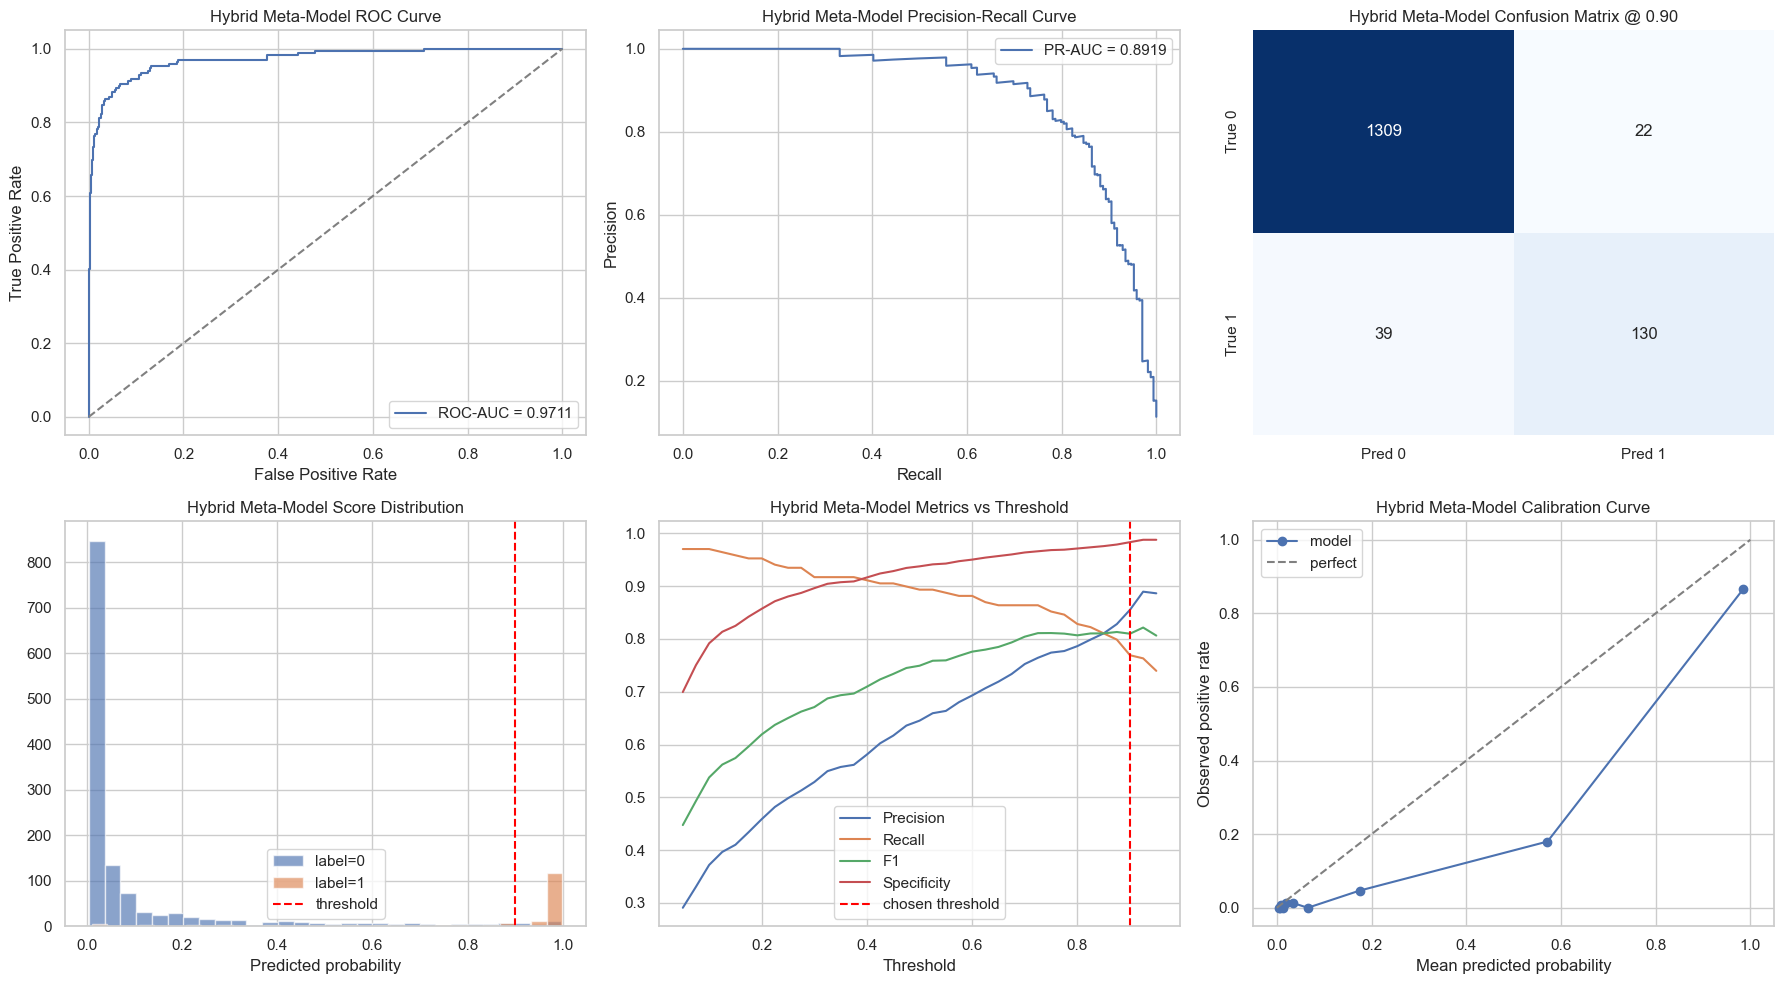

In [19]:
plot_evaluation_dashboard(
    y_true=experiment["test_signal_df"]["label"].to_numpy(),
    y_prob=experiment["meta_result"]["test_prob"],
    threshold=experiment["meta_result"]["threshold"],
    title_prefix="Hybrid Meta-Model",
)


In [20]:
display(top_hybrid_alerts(experiment["test_signal_df"], top_n=25))


,node_id,label,hybrid_score,hybrid_pred,tabular_score,motif_score,gnn_score,anomaly_score
865,1190237,1,0.999202,1,0.978267,0.993226,0.997165,0.140323
1321,1190806,1,0.999196,1,0.976096,0.993226,0.993020,0.120569
1199,1225981,1,0.999191,1,0.974483,0.993226,0.995492,0.129758
613,1215546,1,0.999186,1,0.973784,0.997937,0.988208,0.150966
517,1259267,1,0.999177,1,0.976327,0.997458,0.978073,0.138664
724,1221954,1,0.999137,1,0.971994,0.995910,0.999445,0.266019
672,1190449,1,0.999044,1,0.976096,0.989235,0.935807,0.122442
1261,1266498,1,0.999030,1,0.931888,0.993226,0.996603,0.140865
255,711498,1,0.999013,1,0.955341,0.997284,0.941081,0.133234
599,1201946,1,0.998993,1,0.921718,0.998839,0.989917,0.160603


In [21]:
motif_columns = [column for column in experiment["motif_df"].columns if column.startswith("motif_")]
test_alerts = (
    experiment["test_signal_df"][["node_id", "hybrid_score", "label"]]
    .merge(experiment["motif_df"], on="node_id", how="left")
    .sort_values("hybrid_score", ascending=False)
    .head(15)
)
display(test_alerts[["node_id", "label", "hybrid_score"] + motif_columns[:8]])


,node_id,label,hybrid_score,motif_in_degree,motif_out_degree,motif_total_degree,motif_pagerank,motif_component_size,motif_triangle_count,motif_clustering,motif_reciprocal_partner_count
865,1190237,1,0.999202,0.0,1.0,1.0,0.000019,9763.0,0.0,0.0,0.0
1321,1190806,1,0.999196,0.0,1.0,1.0,0.000019,9763.0,0.0,0.0,0.0
1199,1225981,1,0.999191,0.0,1.0,1.0,0.000019,9763.0,0.0,0.0,0.0
613,1215546,1,0.999186,1.0,0.0,1.0,0.000030,9763.0,0.0,0.0,0.0
517,1259267,1,0.999177,1.0,0.0,1.0,0.000020,9763.0,0.0,0.0,0.0
724,1221954,1,0.999137,1.0,0.0,1.0,0.000028,3.0,0.0,0.0,0.0
672,1190449,1,0.999044,2.0,0.0,2.0,0.000025,9763.0,0.0,0.0,0.0
1261,1266498,1,0.999030,0.0,1.0,1.0,0.000019,9763.0,0.0,0.0,0.0
255,711498,1,0.999013,1.0,0.0,1.0,0.000024,9763.0,0.0,0.0,0.0
599,1201946,1,0.998993,0.0,0.0,0.0,0.000000,1.0,0.0,0.0,0.0


## Readout

If the `hybrid_meta` row wins in `PR-AUC`, `F1`, or `MCC`, you can argue that:

- tabular features capture wallet-level semantics
- motif features capture suspicious local trading structure
- the GNN captures message-passing context
- anomaly detection adds weak-label robustness
- the meta-model learns how to combine them into a final risk score
